<a href="https://colab.research.google.com/github/Doumbia07/DI_Bootcamp/blob/main/ExercisesXPGold_KMeans_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
Dossier du dataset : /kaggle/input/breast-cancer-wisconsin-data
 Dataset chargé avec pandas via kagglehub
Dimensions : (569, 33)

 Premières lignes :
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974         

/tmp/ipykernel_30431/3730279866.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='diagnosis', palette='magma')


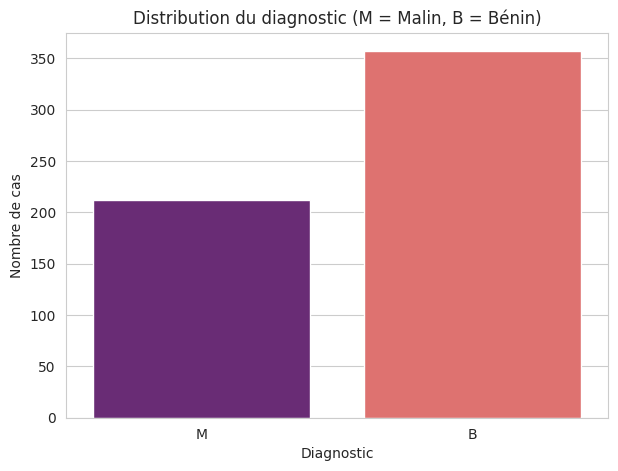


 Nombre de valeurs uniques : 2
Valeurs : ['M' 'B']
Détail :
diagnosis
B    357
M    212
Name: count, dtype: int64

 Mapping effectué : M->1 (malin), B->0 (bénin)
  diagnosis  diagnosis_num
0         M              1
1         M              1
2         M              1
3         M              1
4         M              1

Taille train : (455, 30)
Taille test : (114, 30)

 Logistic Regression accuracy : 0.9649
 KNN accuracy : 0.9561
 Random Forest accuracy : 0.9737
 SVM accuracy : 0.9737

 MEILLEUR MODÈLE : Random Forest avec accuracy 0.9737

Classement :
   Random Forest: 0.9737
   SVM: 0.9737
   Logistic Regression: 0.9649
   KNN: 0.9561


In [ ]:
# 1. Installer kagglehub


# 2. Importer les bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

np.random.seed(42)

# 3. Télécharger le dataset via kagglehub
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
print("Dossier du dataset :", path)

# Trouver le fichier CSV
fichier_csv = os.path.join(path, "data.csv")
df = pd.read_csv(fichier_csv)

print(" Dataset chargé avec pandas via kagglehub")
print(f"Dimensions : {df.shape}")

# 4. Afficher les premières lignes
print("\n Premières lignes :")
print(df.head())

# 5. Vérifier les valeurs manquantes
print("\n Valeurs manquantes :")
print(df.isnull().sum().sort_values(ascending=False).head(10))

# 6. Supprimer la colonne 'id' (inutile) et la colonne 'Unnamed: 32' si elle existe
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)
    print("Colonne 'id' supprimée")
if 'Unnamed: 32' in df.columns:
    df.drop('Unnamed: 32', axis=1, inplace=True)
    print("Colonne 'Unnamed: 32' supprimée") # Added print statement for clarity

# Supprimer les lignes avec des valeurs manquantes (peu nombreuses) APRÈS avoir géré les colonnes inutiles
df.dropna(inplace=True)

# 7. Countplot avec palette magma
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='diagnosis', palette='magma')
plt.title("Distribution du diagnostic (M = Malin, B = Bénin)")
plt.xlabel("Diagnostic")
plt.ylabel("Nombre de cas")
plt.show()

# 8. Compter les valeurs uniques dans 'diagnosis'
print("\n Nombre de valeurs uniques :", df['diagnosis'].nunique())
print("Valeurs :", df['diagnosis'].unique())
print("Détail :")
print(df['diagnosis'].value_counts())

# 9. Mapper catégoriel -> numérique (M=1, B=0)
mapping = {'M': 1, 'B': 0}
df['diagnosis_num'] = df['diagnosis'].map(mapping)
print("\n Mapping effectué : M->1 (malin), B->0 (bénin)")
print(df[['diagnosis', 'diagnosis_num']].head())

# 10. Séparer X et y
X = df.drop(['diagnosis', 'diagnosis_num'], axis=1)
y = df['diagnosis_num']

# 11. Split train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)
print(f"\nTaille train : {X_train.shape}")
print(f"Taille test : {X_test.shape}")

# 12. Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 13. Modèles et accuracy
resultats = {}

# Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=2000)
lr.fit(X_train_scaled, y_train)
acc_lr = accuracy_score(y_test, lr.predict(X_test_scaled))
resultats['Logistic Regression'] = acc_lr
print(f"\n Logistic Regression accuracy : {acc_lr:.4f}")

# KNN
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
acc_knn = accuracy_score(y_test, knn.predict(X_test_scaled))
resultats['KNN'] = acc_knn
print(f" KNN accuracy : {acc_knn:.4f}")

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
acc_rf = accuracy_score(y_test, rf.predict(X_test))
resultats['Random Forest'] = acc_rf
print(f" Random Forest accuracy : {acc_rf:.4f}")

# SVM
svm = SVC(random_state=42)
svm.fit(X_train_scaled, y_train)
acc_svm = accuracy_score(y_test, svm.predict(X_test_scaled))
resultats['SVM'] = acc_svm
print(f" SVM accuracy : {acc_svm:.4f}")

# 14. Meilleur modèle
best = max(resultats, key=resultats.get)
print("\n" + "="*50)
print(f" MEILLEUR MODÈLE : {best} avec accuracy {resultats[best]:.4f}")
print("="*50)
print("\nClassement :")
for m, a in sorted(resultats.items(), key=lambda x: x[1], reverse=True):
    print(f"   {m}: {a:.4f}")